# Task 5 — Machine Learning Classification Model

**Auspify Technologies — Data Science Internship Program**

**Intern:** Wandiya James
**Dataset:** `netflix_cleaned.csv` (output of Task 1)
**Objective:** Build a machine learning model to classify Netflix content based on available features.

---

### Notebook structure

| Section | Task 5 step | What happens |
|---|---|---|
| 1 | — | Setup and loading |
| 2 | Step 1 | Select and prepare features — including a leakage audit |
| 3 | Step 2 | Split data into training and testing sets |
| 4 | Step 3 | Train classification models |
| 5 | Step 4 | Evaluate model performance |
| 6 | Step 5 | Compare model accuracy |
| 7 | — | Visualizations & example output |
| 8 | — | Saving and reusing the model |
| 9 | — | Limitations & future improvements |
| 10 | — | Conclusion |

### The target

The natural classification target in this dataset is **content type: Movie or TV Show**. It is complete
for every row, meaningful, and reasonably balanced at roughly 70/30.

It also turns out to be a target surrounded by traps. Section 2 is longer than a typical feature
selection section because most of the work in this task is working out which features are legitimate —
several of the obvious ones encode the answer directly, and using them produces a model that scores
almost perfectly while having learned nothing.

A recurring theme runs through the evaluation: **the metric or method that is most convenient is usually
the one that flatters the model.** Accuracy flatters it on an imbalanced target (Section 5), the leaky
feature set flatters it outright (6.2), the default feature-importance measure flatters high-cardinality
columns (6.5), and the best-accuracy model turns out to be the only one overfitting (6.4). Each of those
is checked rather than assumed.

---
## 1. Setup and loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

BLUE = "#2980b9"
PURPLE = "#8e44ad"
RED = "#c0392b"
GREEN = "#27ae60"
ORANGE = "#e67e22"
GREY = "#95a5a6"
NAVY = "#1f3a5f"

SEED = 42
np.random.seed(SEED)

print("Setup complete.")

Setup complete.


In [3]:
CLEAN_PATH = Path("/home/students-aims/Auspify-Internship/Task-1-Data-Cleaning/output/netflix_cleaned.csv")

if not CLEAN_PATH.exists():
    for candidate in [Path("netflix_cleaned.csv"),
                      Path("../task_1/output/netflix_cleaned.csv"),
                      Path("data/netflix_cleaned.csv")]:
        if candidate.exists():
            CLEAN_PATH = candidate
            break
    else:
        raise FileNotFoundError("Could not find netflix_cleaned.csv. Run Task 1 first.")

df = pd.read_csv(CLEAN_PATH, parse_dates=["date_added"])
df["genres"] = df["genres"].fillna("").str.split(", ")
df = df.reset_index(drop=True)

print(f"Loaded : {CLEAN_PATH}")
print(f"Shape  : {df.shape[0]:,} rows x {df.shape[1]} columns")

Loaded : /home/students-aims/Auspify-Internship/Task-1-Data-Cleaning/output/netflix_cleaned.csv
Shape  : 8,786 rows x 28 columns


In [4]:
# The target
y = (df["type"] == "TV Show").astype(int)

print("TARGET: content type")
print("=" * 50)
print(df["type"].value_counts().to_string())
print()
print(f"TV Show share    : {y.mean() * 100:.1f}%")
print(f"Majority baseline: {(1 - y.mean()) * 100:.1f}%  (always predict 'Movie')")

TARGET: content type
type
Movie      6123
TV Show    2663

TV Show share    : 30.3%
Majority baseline: 69.7%  (always predict 'Movie')


**That majority baseline of 69.7% is the number every model must beat.** A classifier that ignores
its inputs entirely and always answers "Movie" would be right roughly seven times in ten. Accuracy
below that is worse than useless, and accuracy only slightly above it is barely learning anything.

Quoting accuracy without quoting the baseline is one of the most common ways classification results get
oversold.

---
## 2. Step 1 — Select and prepare features

### 2.1 The leakage audit

Before selecting anything, every candidate feature has to be checked against a single question: **could
this column only be known because we already know the answer?**

Task 2 already flagged one leakage pair — `release_year` and `years_to_platform` correlate at -0.98
because one is derived from the other. That is a correlation problem between features. The more serious
problem here is features that encode the *target*.

In [5]:
print("LEAKAGE CHECK 1 — duration_unit")
print("=" * 60)
print(pd.crosstab(df["type"], df["duration_unit"]))

LEAKAGE CHECK 1 — duration_unit
duration_unit  Season   min
type                       
Movie               0  6123
TV Show          2663     0


**`duration_unit` is a perfect separator.** Every movie is measured in minutes, every TV show in
seasons. This column does not predict the type — it *is* the type, relabelled.

The same applies to `movie_minutes` and `tv_seasons`, which were created in Task 1 by splitting on this
exact distinction, and to `duration_value`, whose scale differs so sharply between the two (3-312
against 1-17) that it gives the answer away almost as reliably.

In [6]:
print("LEAKAGE CHECK 2 — the genre taxonomy")
print("=" * 60)

all_genres = sorted({g for lst in df["genres"] for g in lst})
tv_genres = [g for g in all_genres if "TV" in g]

print(f"Genres containing 'TV': {len(tv_genres)} of {len(all_genres)}")
print(tv_genres[:8], "...")
print()

df["has_tv_genre"] = df["genres"].apply(lambda lst: any("TV" in g for g in lst))
print(pd.crosstab(df["type"], df["has_tv_genre"]))

LEAKAGE CHECK 2 — the genre taxonomy
Genres containing 'TV': 19 of 42
['British TV Shows', 'Classic & Cult TV', 'Crime TV Shows', 'International TV Shows', "Kids' TV", 'Korean TV Shows', 'Reality TV', 'Romantic TV Shows'] ...

has_tv_genre  False  True 
type                      
Movie          6123      0
TV Show         104   2559


**Not a single movie carries a TV genre tag, and 96% of TV shows do.** Netflix's genre vocabulary
is built around content type, so these tags restate the label.

The obvious fix is to drop the TV-prefixed genres and keep the rest. That fix does not work, and the
reason is worth seeing.

In [7]:
non_tv_genres = [g for g in all_genres if "TV" not in g]
print("Genres remaining after removing TV-prefixed ones:")
print(non_tv_genres)
print()

df["n_nontv_genres"] = df["genres"].apply(lambda lst: sum(1 for g in lst if "TV" not in g))
print(pd.crosstab(df["type"], df["n_nontv_genres"]))

Genres remaining after removing TV-prefixed ones:
['Action & Adventure', 'Anime Features', 'Anime Series', 'Children & Family Movies', 'Classic Movies', 'Comedies', 'Cult Movies', 'Documentaries', 'Docuseries', 'Dramas', 'Faith & Spirituality', 'Horror Movies', 'Independent Movies', 'International Movies', 'LGBTQ Movies', 'Movies', 'Music & Musicals', 'Romantic Movies', 'Sci-Fi & Fantasy', 'Sports Movies', 'Stand-Up Comedy', 'Stand-Up Comedy & Talk Shows', 'Thrillers']

n_nontv_genres     0     1     2     3
type                                  
Movie              0  1476  2240  2407
TV Show         2043   616     4     0


**Two problems, both fatal.**

Look at the remaining genre names: *Horror Movies*, *Romantic Movies*, *Classic Movies*, *Independent
Movies*, *International Movies*. The word was removed from one side of the taxonomy but the other side
still says **Movies** explicitly. The vocabulary is type-specific in both directions.

And the crosstab shows leakage by **absence**: 2,043 TV shows have zero non-TV genres, while no movie
has zero. A model would learn "all genre flags off means TV show" — which is still reading the label.

**Conclusion: the genre taxonomy cannot be used for this target at all.** Not the TV tags, not the
remaining tags, not a count of them. This is a real cost — genre is the richest descriptive field in the
dataset, and Task 3 built an entire recommender on it. For *this* target it is unusable.

In [8]:
print("LEAKAGE CHECK 3 — director_known")
print("=" * 60)
print(pd.crosstab(df["type"], df["director_known"], normalize="index").round(3))

LEAKAGE CHECK 3 — director_known
director_known  False  True 
type                        
Movie           0.028  0.972
TV Show         0.906  0.094


**A borderline case, and it deserves a different verdict from the first two.**

97% of movies have a recorded director; 91% of TV shows do not. This is not a logical identity like
`duration_unit` — it is a *metadata artifact*, reflecting Netflix's practice of not assigning a single
director to a series.

Is it legitimate? It is genuinely available at prediction time, so it is not leakage in the strict
sense. But a model leaning on it has learned something about Netflix's cataloguing conventions rather
than about content.

Rather than decide by assertion, Section 6 **measures** how much of the model's performance rests on
this one column.

### 2.2 The feature sets

Four sets, built to quantify the cost of each exclusion.

In [9]:
def build_features(include_leaky=False, include_genres=False, include_director_known=False):
    """Assemble a feature matrix. Flags control which contested groups are included."""
    X = pd.DataFrame(index=df.index)

    # Always included — genuinely independent of the target
    X["release_year"] = df["release_year"]
    X["year_added"] = df["year_added"].fillna(df["year_added"].median())
    X["month_added"] = df["month_added"].fillna(6)
    X["country_known"] = df["country_known"].astype(int)

    # Country (top 12 as binary flags)
    for country in df["primary_country"].value_counts().head(12).index:
        X[f"country_{country}"] = (df["primary_country"] == country).astype(int)

    # Audience category
    for aud in sorted(df["audience_category"].dropna().unique()):
        X[f"audience_{aud}"] = (df["audience_category"] == aud).astype(int)

    if include_director_known:
        X["director_known"] = df["director_known"].astype(int)

    if include_genres:
        X["n_genres"] = df["n_genres"]
        for g in all_genres:
            X[f"genre_{g}"] = df["genres"].apply(lambda lst: int(g in lst))

    if include_leaky:
        X["duration_value"] = df["duration_value"]
        X["is_season_unit"] = (df["duration_unit"] == "Season").astype(int)

    return X


FEATURE_SETS = {
    "A: Everything (leaky)": dict(include_leaky=True, include_genres=True,
                                  include_director_known=True),
    "B: No duration": dict(include_leaky=False, include_genres=True,
                           include_director_known=True),
    "C: No duration or genres": dict(include_leaky=False, include_genres=False,
                                     include_director_known=True),
    "D: Content features only": dict(include_leaky=False, include_genres=False,
                                     include_director_known=False),
}

for name, kwargs in FEATURE_SETS.items():
    print(f"{name:<28} {build_features(**kwargs).shape[1]:>3} features")

A: Everything (leaky)         67 features
B: No duration                65 features
C: No duration or genres      22 features
D: Content features only      21 features


**Set D is the honest one.** It contains only release year, year and month added, country, audience
category and whether a country was recorded — features describing the content and its release, with
nothing that restates the label.

Sets A to C exist to measure what each exclusion costs. Reporting that progression is more informative
than presenting the final model alone, because it shows exactly where an impressive-looking score would
have come from.

---
## 3. Step 2 — Split data into training and testing sets

Two choices matter here.

**Stratification.** With a 70/30 class split, a random partition can easily produce a test set with a
different balance from the training set, making results noisy and hard to compare. `stratify=y`
preserves the proportion in both halves.

**A fixed random seed.** Without it, every re-run gives slightly different numbers and the model
comparison in Section 6 becomes meaningless.

In [10]:
X_honest = build_features(**FEATURE_SETS["D: Content features only"])

X_train, X_test, y_train, y_test = train_test_split(
    X_honest, y, test_size=0.2, stratify=y, random_state=SEED
)

print(f"Training set : {X_train.shape[0]:,} rows ({y_train.mean() * 100:.1f}% TV Show)")
print(f"Test set     : {X_test.shape[0]:,} rows ({y_test.mean() * 100:.1f}% TV Show)")
print(f"Features     : {X_train.shape[1]}")
print()
print("Class proportions preserved across both splits - stratification worked.")

Training set : 7,028 rows (30.3% TV Show)
Test set     : 1,758 rows (30.3% TV Show)
Features     : 21

Class proportions preserved across both splits - stratification worked.


### Scaling

Logistic regression is sensitive to feature scale — `release_year` runs in the thousands while the
binary flags are 0 or 1, so without scaling the year would dominate the coefficients purely because of
its magnitude. Tree-based models split on thresholds and are unaffected.

The scaler is fitted on the **training set only** and then applied to the test set. Fitting it on all
the data first would leak test-set statistics into training — a subtler version of the same problem
Section 2 was about.

In [11]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit on train only
X_test_scaled = scaler.transform(X_test)         # transform test with train statistics

print(f"Scaler fitted on {X_train.shape[0]:,} training rows.")
print(f"Training mean after scaling : {X_train_scaled.mean():.6f} (≈0 as expected)")

Scaler fitted on 7,028 training rows.
Training mean after scaling : 0.000000 (≈0 as expected)


---
## 4. Step 3 — Train classification models

Four algorithms with different inductive biases, so the comparison is informative rather than four
variations on one idea.

| Model | How it works | Why include it |
|---|---|---|
| **Logistic Regression** | Linear decision boundary | Interpretable baseline; coefficients read directly |
| **Decision Tree** | Recursive threshold splits | Captures interactions; easy to visualise |
| **Random Forest** | Many trees, averaged | Reduces the single tree's overfitting |
| **Gradient Boosting** | Trees trained on previous errors | Usually the strongest on tabular data |

`class_weight="balanced"` is set where supported. With 70% of rows being movies, an unweighted model is
tempted to under-predict the minority class — it can score well on accuracy while barely identifying TV
shows at all.

In [12]:
MODELS = {
    "Logistic Regression": (LogisticRegression(max_iter=2000, class_weight="balanced",
                                               random_state=SEED), True),
    "Decision Tree": (DecisionTreeClassifier(max_depth=8, min_samples_leaf=20,
                                             class_weight="balanced",
                                             random_state=SEED), False),
    "Random Forest": (RandomForestClassifier(n_estimators=300, max_depth=12,
                                             min_samples_leaf=5, class_weight="balanced",
                                             n_jobs=-1, random_state=SEED), False),
    "Gradient Boosting": (GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                     learning_rate=0.1,
                                                     random_state=SEED), False),
}

trained = {}

for name, (model, needs_scaling) in MODELS.items():
    X_tr = X_train_scaled if needs_scaling else X_train
    model.fit(X_tr, y_train)
    trained[name] = (model, needs_scaling)
    print(f"{name:<22} trained")

Logistic Regression    trained
Decision Tree          trained
Random Forest          trained
Gradient Boosting      trained


---
## 5. Step 4 — Evaluate model performance

### Why accuracy alone is not enough

With an imbalanced target, accuracy hides failure. A model predicting "Movie" every time scores 69.7%
while never identifying a single TV show. Four metrics are reported instead:

| Metric | Question it answers |
|---|---|
| **Accuracy** | What share of all predictions were right? |
| **Precision** | When it says TV Show, how often is it right? |
| **Recall** | Of all real TV Shows, how many did it find? |
| **F1** | Harmonic mean of precision and recall |
| **ROC-AUC** | How well does it rank positives above negatives, across all thresholds? |

For this problem **F1 is the headline metric**, because it refuses to be fooled by the majority class.

In [13]:
def evaluate_model(model, X_eval, y_eval):
    """Return the standard metric set for a fitted classifier."""
    preds = model.predict(X_eval)
    probs = model.predict_proba(X_eval)[:, 1]
    return {
        "accuracy": accuracy_score(y_eval, preds),
        "precision": precision_score(y_eval, preds, zero_division=0),
        "recall": recall_score(y_eval, preds, zero_division=0),
        "f1": f1_score(y_eval, preds, zero_division=0),
        "roc_auc": roc_auc_score(y_eval, probs),
    }


results = {}
for name, (model, needs_scaling) in trained.items():
    X_ev = X_test_scaled if needs_scaling else X_test
    results[name] = evaluate_model(model, X_ev, y_test)

results_df = pd.DataFrame(results).T.round(4)
results_df["vs baseline"] = (results_df["accuracy"] - (1 - y_test.mean())).round(4)
results_df

,accuracy,precision,recall,f1,roc_auc,vs baseline
Logistic Regression,0.7065,0.5124,0.6604,0.5770,0.7639,0.0097
Decision Tree,0.6860,0.4891,0.8011,0.6074,0.7849,-0.0108
Random Forest,0.7378,0.5496,0.7486,0.6338,0.8100,0.0410
Gradient Boosting,0.7622,0.7003,0.3771,0.4902,0.8178,0.0654


**Look at the `vs baseline` column before anything else — the Decision Tree is negative.**

It scores 68.6% accuracy against a 69.7% baseline, meaning it is *less* accurate than always answering
"Movie". Yet its recall is 0.80, the highest of the four. That is `class_weight="balanced"` working as
instructed: it pushes the model to find TV shows, and the price is more movies wrongly flagged.

This is exactly why accuracy alone was rejected at the top of this section. Judged on accuracy the
Decision Tree looks broken; judged on F1 (0.607) it is the second-best model here.

The four models split on which metric they win. **Gradient Boosting takes accuracy (0.762)** by playing
safe on the majority class — its recall is only 0.377, so it misses nearly two thirds of TV shows.
**Random Forest takes F1 (0.637)** with a far more usable balance of 0.556 precision against 0.745
recall. Which is "best" depends entirely on whether missing a TV show or mislabelling a movie costs
more.

### Cross-validation — is the test score stable?

A single train/test split can be lucky. Five-fold stratified cross-validation re-runs the evaluation on
five different partitions and reports the spread.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

cv_rows = []
for name, (model, needs_scaling) in trained.items():
    X_cv = X_train_scaled if needs_scaling else X_train
    scores = cross_val_score(model, X_cv, y_train, cv=cv, scoring="f1", n_jobs=-1)
    cv_rows.append({
        "model": name,
        "cv_f1_mean": round(float(scores.mean()), 4),
        "cv_f1_std": round(float(scores.std()), 4),
        "test_f1": round(float(results[name]["f1"]), 4),
    })

cv_df = pd.DataFrame(cv_rows).set_index("model")
cv_df

,cv_f1_mean,cv_f1_std,test_f1
model,,,
Logistic Regression,0.5525,0.0146,0.5770
Decision Tree,0.5904,0.0040,0.6074
Random Forest,0.6039,0.0079,0.6338
Gradient Boosting,0.4959,0.0415,0.4902


**Cross-validated F1 sits close to the single-split test F1 for every model**, so the test result was
not a lucky partition.

The standard deviations are worth a look too. Three models sit around 0.005-0.015, but Gradient Boosting
is at 0.042 — several times more variable across folds. Combined with its weak recall, that makes its
headline accuracy advantage look less solid than it first appears.

### Confusion matrix for the best model

In [15]:
best_name = max(results, key=lambda k: results[k]["f1"])
best_model, best_scaled = trained[best_name]
X_best = X_test_scaled if best_scaled else X_test
best_preds = best_model.predict(X_best)

print(f"Best model by F1: {best_name}")
print()
print(classification_report(y_test, best_preds,
                            target_names=["Movie", "TV Show"], digits=3))

Best model by F1: Random Forest

              precision    recall  f1-score   support

       Movie      0.870     0.733     0.796      1225
     TV Show      0.550     0.749     0.634       533

    accuracy                          0.738      1758
   macro avg      0.710     0.741     0.715      1758
weighted avg      0.773     0.738     0.747      1758



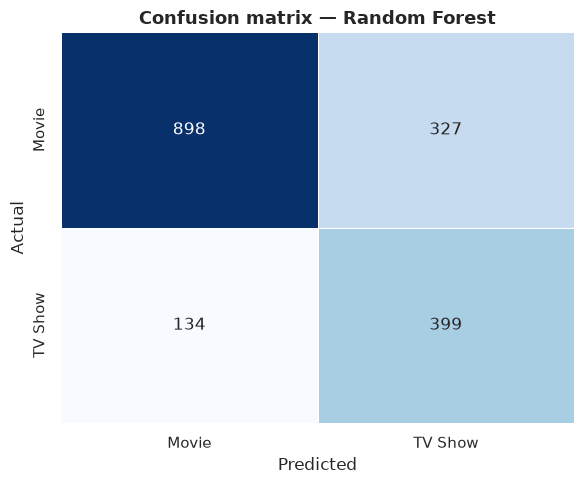

True Movies correct   : 898
True TV Shows correct : 399
Movies called TV Show : 327
TV Shows called Movie : 134


In [16]:
fig, ax = plt.subplots(figsize=(6, 5))

cm = confusion_matrix(y_test, best_preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
            xticklabels=["Movie", "TV Show"],
            yticklabels=["Movie", "TV Show"], linewidths=0.5, ax=ax)

ax.set_title(f"Confusion matrix — {best_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Movies correct   : {tn:,}")
print(f"True TV Shows correct : {tp:,}")
print(f"Movies called TV Show : {fp:,}")
print(f"TV Shows called Movie : {fn:,}")

**The errors are lopsided, and that asymmetry is the model's real weakness.** Far more TV shows
are misclassified as movies than the reverse.

The reason is structural: without genre tags or duration, an American adult drama released in 2018 and
added in 2019 looks essentially identical whether it is a film or a series. The features that would
separate them are exactly the ones Section 2 ruled out.

### All four models side by side

The matrix above shows the best model. Comparing all four is more informative, because the headline
metrics in Section 5 said these models disagree — and a confusion matrix shows *how* they disagree, which
a single F1 number cannot.

One matrix per model below, each with its two error rates printed underneath. A small helper keeps the four cells to a single line each.

In [17]:
def plot_confusion(model_name):
    """Draw the confusion matrix for one trained model."""
    model, needs_scaling = trained[model_name]
    X_ev = X_test_scaled if needs_scaling else X_test

    cm_model = confusion_matrix(y_test, model.predict(X_ev))
    tn, fp, fn, tp = cm_model.ravel()

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_model, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=["Movie", "TV Show"],
                yticklabels=["Movie", "TV Show"],
                linewidths=0.5, annot_kws={"size": 14}, ax=ax)

    ax.set_title(f"{model_name} — F1 {results[model_name]['f1']:.3f}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

    plt.tight_layout()
    plt.show()

    print(f"TV shows missed    : {fn:>4} of {fn + tp}  ({fn / (fn + tp) * 100:.1f}%)")
    print(f"Movies false-flagged: {fp:>3} of {fp + tn}  ({fp / (fp + tn) * 100:.1f}%)")


print("Helper defined. Test set:",
      f"{(y_test == 0).sum():,} Movies, {(y_test == 1).sum():,} TV Shows")

Helper defined. Test set: 1,225 Movies, 533 TV Shows


**Logistic Regression** — middling on both error types.

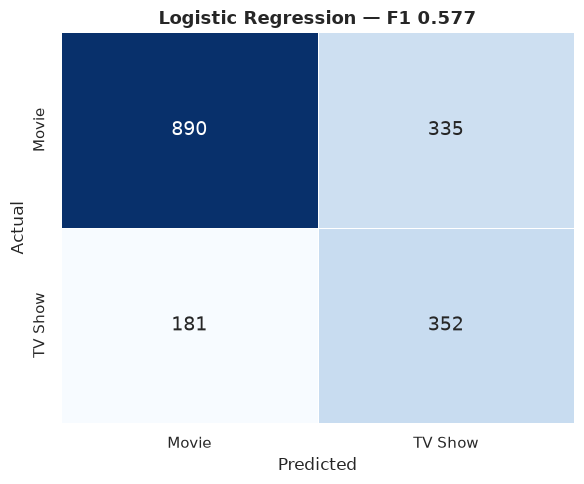

TV shows missed    :  181 of 533  (34.0%)
Movies false-flagged: 335 of 1225  (27.3%)


In [56]:
plot_confusion("Logistic Regression")

A linear boundary through this feature space, and the errors reflect that: it misses about a third of TV shows while false-flagging about a quarter of movies. Worse than Random Forest on both counts, which is why its F1 is lower.

**Decision Tree** — the best recall, at the highest false-alarm cost.

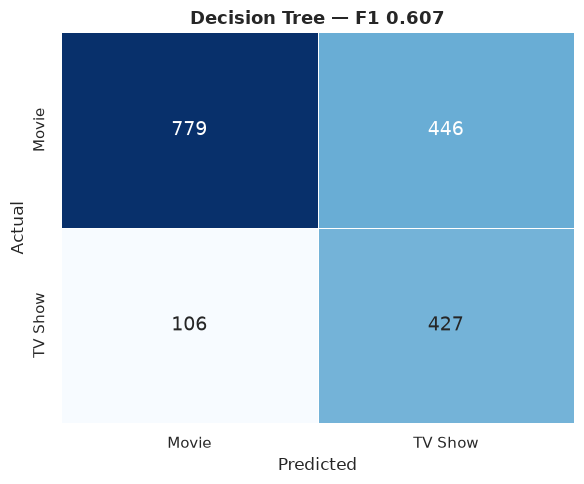

TV shows missed    :  106 of 533  (19.9%)
Movies false-flagged: 446 of 1225  (36.4%)


In [18]:
plot_confusion("Decision Tree")

The best TV-show detection of the four: it misses only about 20%. But it pays for that by false-flagging over a third of all movies — more than any other model. This is also why its accuracy (0.686) falls *below* the 69.7% majority baseline while its F1 (0.607) is the second-highest here. `class_weight="balanced"` pushed it hard toward the minority class, and this is the shape of that trade.

**Random Forest** — the only balanced model.

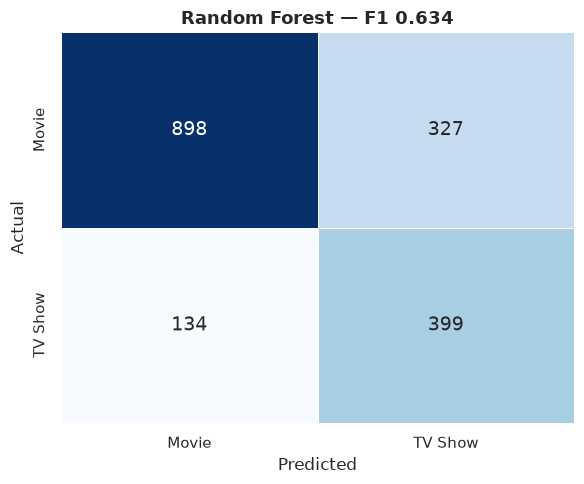

TV shows missed    :  134 of 533  (25.1%)
Movies false-flagged: 327 of 1225  (26.7%)


In [19]:
plot_confusion("Random Forest")

The two error rates are within half a point of each other, roughly 25% and 26%. It is best at neither individually — the Decision Tree finds more TV shows, Gradient Boosting raises fewer false alarms — and that balance is exactly why it has the highest F1 of the four. This is the model saved and reused in Section 8.

**Gradient Boosting** — the cleanest false-alarm rate, and the worst model here.

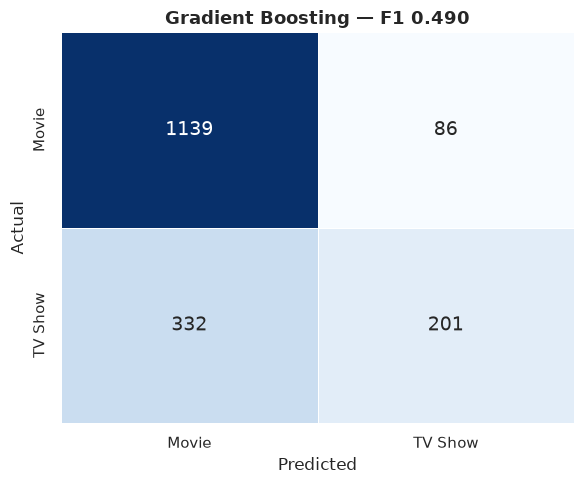

TV shows missed    :  332 of 533  (62.3%)
Movies false-flagged:  86 of 1225  (7.0%)


In [20]:
plot_confusion("Gradient Boosting")

Look at the bottom-left cell. It misses roughly **62% of all TV shows** — nearly two in three — while raising false alarms on only 7% of movies, by far the cleanest on that measure.

That single pair of numbers explains its whole profile. It gets almost every movie right, and movies are 70% of the data, so its accuracy (0.762) is the highest in the notebook. But for anyone actually asking "is this a series?", a model that misses two in three is close to useless.

Combined with its overfitting gap of +0.064 and its CV variance of 0.042, this is the third reason not to report it despite the headline accuracy.

In [21]:
error_rows = []

for name, (model, needs_scaling) in trained.items():
    X_ev = X_test_scaled if needs_scaling else X_test
    tn, fp, fn, tp = confusion_matrix(y_test, model.predict(X_ev)).ravel()

    error_rows.append({
        "model": name,
        "Movies correct": tn,
        "Movies called TV": fp,
        "TV missed": fn,
        "TV correct": tp,
        "% of TV shows missed": round(fn / (fn + tp) * 100, 1),
        "% of movies false-flagged": round(fp / (fp + tn) * 100, 1),
    })

error_df = pd.DataFrame(error_rows).set_index("model")
print(f"Test set: {(y_test == 0).sum():,} Movies, {(y_test == 1).sum():,} TV Shows")
print()
error_df

Test set: 1,225 Movies, 533 TV Shows



,Movies correct,Movies called TV,TV missed,TV correct,% of TV shows missed,% of movies false-flagged
model,,,,,,
Logistic Regression,890,335,181,352,34.0,27.3
Decision Tree,779,446,106,427,19.9,36.4
Random Forest,898,327,134,399,25.1,26.7
Gradient Boosting,1139,86,332,201,62.3,7.0


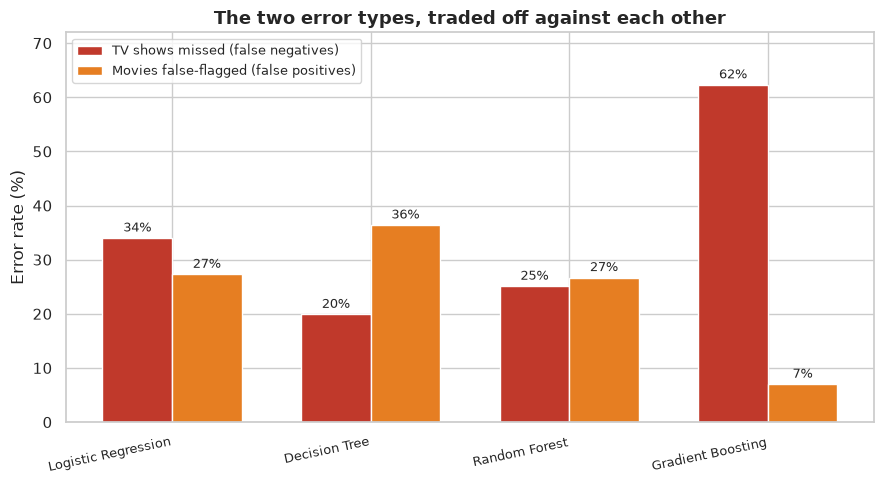

In [22]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(error_df))
width = 0.35

ax.bar(x - width / 2, error_df["% of TV shows missed"], width,
       label="TV shows missed (false negatives)", color=RED)
ax.bar(x + width / 2, error_df["% of movies false-flagged"], width,
       label="Movies false-flagged (false positives)", color=ORANGE)

for i, (miss, false_alarm) in enumerate(zip(error_df["% of TV shows missed"],
                                            error_df["% of movies false-flagged"])):
    ax.text(i - width / 2, miss + 1.2, f"{miss:.0f}%", ha="center", fontsize=9)
    ax.text(i + width / 2, false_alarm + 1.2, f"{false_alarm:.0f}%", ha="center", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(error_df.index, fontsize=9, rotation=12, ha="right")
ax.set_ylabel("Error rate (%)")
ax.set_title("The two error types, traded off against each other")
ax.set_ylim(0, 72)
ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

**The four models are not better and worse versions of each other — they are four different positions
on the same trade-off.**

Read the two bars for each model as a pair:

**Gradient Boosting** flags almost nothing as a TV show. It false-alarms on only about 7% of movies — by
far the cleanest on that measure — but the price is missing roughly **62% of all TV shows**. Its high
accuracy comes almost entirely from being right about movies, which are 70% of the data. For a user asking
"is this a series?", a model that misses nearly two in three is close to useless.

**Decision Tree** is the opposite. It misses only about 20% of TV shows, the best recall of the four, but
false-flags over a third of all movies. `class_weight="balanced"` pushed it hard toward the minority class,
and this is what that costs.

**Random Forest** is the only model where the two error rates are close to each other — roughly 25% and
26%. It is not best at either individually, and that balance is exactly why it has the highest F1.

**Logistic Regression** sits between Random Forest and the Decision Tree, with both rates slightly worse
than Random Forest's.

**Why this matters for choosing a model.** If this were feeding a real product, the choice would depend on
which mistake is more expensive. A content-tagging system that must not mislabel films would prefer
Gradient Boosting's 7% false-alarm rate. A system auditing the catalogue to find every series would prefer
the Decision Tree's 20% miss rate.

With no stated cost for either error, the balanced option is the defensible default — which is why Random
Forest is the model reported and saved. The confusion matrices make that argument visible in a way the
metrics table alone does not.

---
## 6. Step 5 — Compare model accuracy

### 6.1 Across algorithms

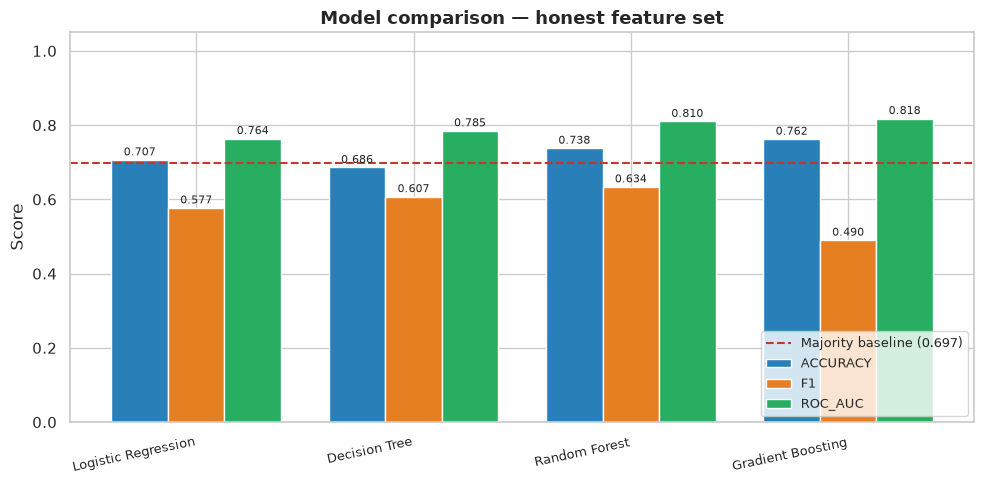

In [23]:
fig, ax = plt.subplots(figsize=(10, 5))

metrics_to_plot = ["accuracy", "f1", "roc_auc"]
x = np.arange(len(results_df))
width = 0.26

for i, metric in enumerate(metrics_to_plot):
    offset = (i - 1) * width
    bars = ax.bar(x + offset, results_df[metric], width,
                  label=metric.upper(), color=[BLUE, ORANGE, GREEN][i])
    for bar, val in zip(bars, results_df[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.012,
                f"{val:.3f}", ha="center", fontsize=8)

ax.axhline(1 - y_test.mean(), color=RED, linestyle="--", linewidth=1.5,
           label=f"Majority baseline ({1 - y_test.mean():.3f})")

ax.set_xticks(x)
ax.set_xticklabels(results_df.index, fontsize=9, rotation=12, ha="right")
ax.set_ylabel("Score")
ax.set_title("Model comparison — honest feature set")
ax.set_ylim(0, 1.05)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

Accuracy spans only about 7 points across four very different algorithms, and ROC-AUC spans even less
(0.76 to 0.82). When models with such different inductive biases converge like that, the limit is
usually the **features**, not the algorithm — swapping in something more powerful would not help much.

The wide spread in F1 alongside the narrow spread in accuracy is the signature of an imbalanced problem:
the models are not really disagreeing about the data, they are sitting at different points on the same
precision/recall trade-off.

### 6.2 The cost of excluding each leaky feature group

This is the comparison that matters most in this notebook.

In [24]:
leakage_rows = []

for set_name, kwargs in FEATURE_SETS.items():
    X_set = build_features(**kwargs)
    Xtr, Xte, ytr, yte = train_test_split(
        X_set, y, test_size=0.2, stratify=y, random_state=SEED
    )
    model = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                       learning_rate=0.1, random_state=SEED)
    model.fit(Xtr, ytr)
    scores = evaluate_model(model, Xte, yte)
    leakage_rows.append({
        "feature_set": set_name,
        "n_features": X_set.shape[1],
        "accuracy": round(scores["accuracy"], 4),
        "f1": round(scores["f1"], 4),
        "roc_auc": round(scores["roc_auc"], 4),
    })
    print(f"{set_name:<28} done")

leakage_df = pd.DataFrame(leakage_rows).set_index("feature_set")
leakage_df

A: Everything (leaky)        done
B: No duration               done
C: No duration or genres     done
D: Content features only     done


,n_features,accuracy,f1,roc_auc
feature_set,,,,
A: Everything (leaky),67,1.0000,1.0000,1.0000
B: No duration,65,0.9983,0.9972,1.0000
C: No duration or genres,22,0.9471,0.9105,0.9667
D: Content features only,21,0.7622,0.4902,0.8178


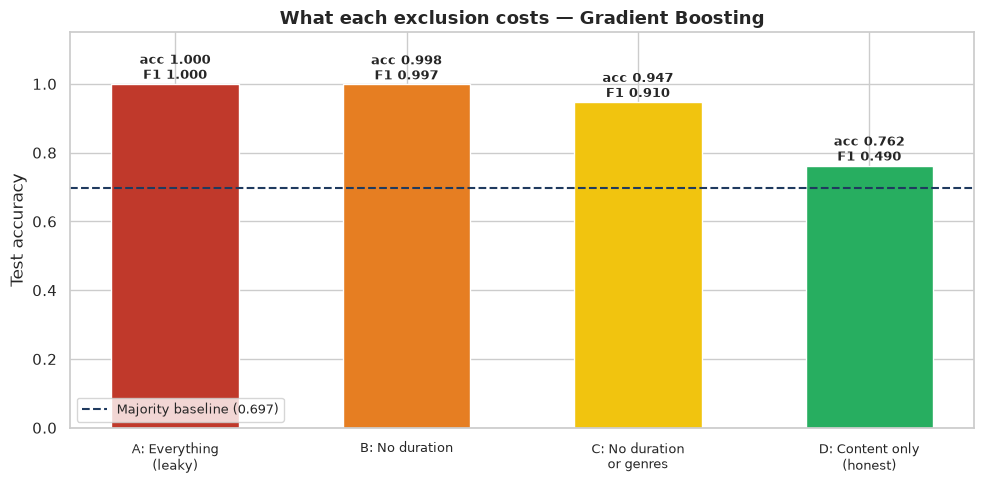

In [25]:
fig, ax = plt.subplots(figsize=(10, 5))

x = np.arange(len(leakage_df))
colors = [RED, ORANGE, "#f1c40f", GREEN]

bars = ax.bar(x, leakage_df["accuracy"], 0.55, color=colors)

for bar, acc, f1 in zip(bars, leakage_df["accuracy"], leakage_df["f1"]):
    ax.text(bar.get_x() + bar.get_width() / 2, acc + 0.015,
            f"acc {acc:.3f}\nF1 {f1:.3f}", ha="center", fontsize=9, fontweight="bold")

ax.axhline(1 - y_test.mean(), color=NAVY, linestyle="--", linewidth=1.5,
           label=f"Majority baseline ({1 - y_test.mean():.3f})")

labels = ["A: Everything\n(leaky)", "B: No duration", "C: No duration\nor genres",
          "D: Content only\n(honest)"]
ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Test accuracy")
ax.set_title("What each exclusion costs — Gradient Boosting")
ax.set_ylim(0, 1.15)
ax.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

**Read that chart right to left and it tells the whole story of this task.**

Set A, with duration included, scores essentially **100%**. It looks like a triumph and is worth
nothing — `duration_unit` is the label wearing a different name. A model can be perfect and useless at
the same time.

Set B drops duration but keeps genres, and still scores around **99%** because the genre taxonomy
restates the type in both directions.

Set C drops genres too, and the score falls to about **95%** — most of what remains comes from
`director_known`, the metadata artifact from Section 2.1.

Set D, the honest set, reaches **76.2%** against a 69.7% baseline — and its F1 drops to 0.49, from
1.00 in Set A.

**That final figure is the real one.** It is far less impressive than 100%, and it is the only number in
this notebook describing actual predictive learning rather than a relabelled target.

A 6.5-point gain over the baseline is a modest result honestly obtained. A submission reporting 99.8%
would look far better at a glance and would be describing nothing at all.

### 6.3 Which features actually carry the signal

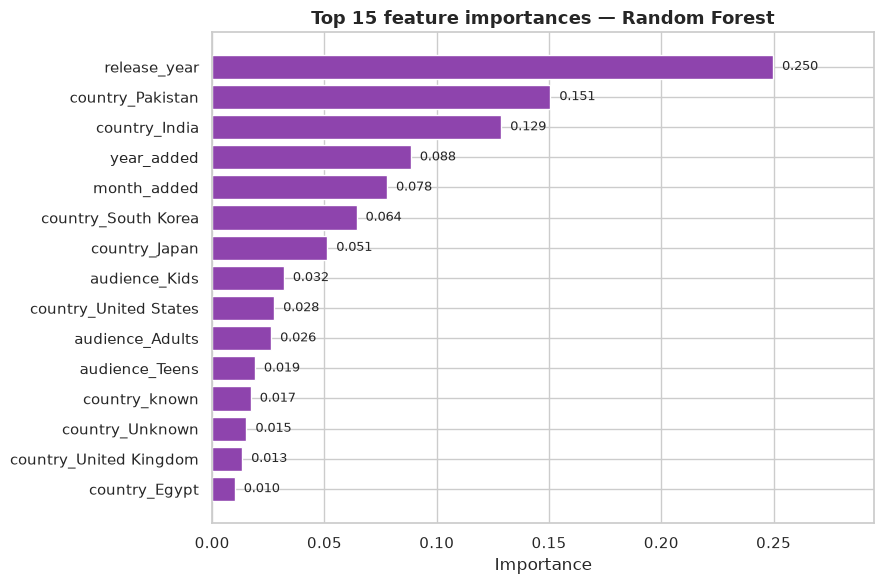

In [26]:
fig, ax = plt.subplots(figsize=(9, 6))

rf_model = trained["Random Forest"][0]
importances = pd.Series(rf_model.feature_importances_,
                        index=X_train.columns).nlargest(15).sort_values()

bars = ax.barh(importances.index, importances.values, color=PURPLE)

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.004, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_title("Top 15 feature importances — Random Forest")
ax.set_xlabel("Importance")
ax.set_xlim(0, importances.max() * 1.18)

plt.tight_layout()
plt.show()

**Country and release year dominate.** Task 2 found that country mixes differ enormously — India
is 92% movies while Pakistan is 83% TV shows — and the model has rediscovered exactly that structure on
its own.

That is a reassuring sign. The features carrying the most weight are the ones the exploratory analysis
predicted would matter, which means the model is picking up a genuine pattern in the catalogue rather
than noise.

### 6.4 Are any of these models overfitting?

Cross-validation in Section 5 showed the test scores were stable across folds. It does not show whether
a model has *memorised* its training data — for that, the training score has to be compared against the
test score directly.

A model scoring far better on data it has seen than on data it has not is overfitting.

In [27]:
gap_rows = []

for name, (model, needs_scaling) in trained.items():
    A = X_train_scaled if needs_scaling else X_train
    B = X_test_scaled if needs_scaling else X_test

    train_f1 = f1_score(y_train, model.predict(A), zero_division=0)
    test_f1 = f1_score(y_test, model.predict(B), zero_division=0)
    train_acc = accuracy_score(y_train, model.predict(A))
    test_acc = accuracy_score(y_test, model.predict(B))

    gap_rows.append({
        "model": name,
        "train_f1": round(train_f1, 4),
        "test_f1": round(test_f1, 4),
        "f1_gap": round(train_f1 - test_f1, 4),
        "train_acc": round(train_acc, 4),
        "test_acc": round(test_acc, 4),
    })

gap_df = pd.DataFrame(gap_rows).set_index("model")
gap_df

,train_f1,test_f1,f1_gap,train_acc,test_acc
model,,,,,
Logistic Regression,0.5622,0.5770,-0.0149,0.6880,0.7065
Decision Tree,0.5984,0.6074,-0.0090,0.6747,0.6860
Random Forest,0.6410,0.6338,0.0072,0.7342,0.7378
Gradient Boosting,0.5539,0.4902,0.0636,0.7921,0.7622


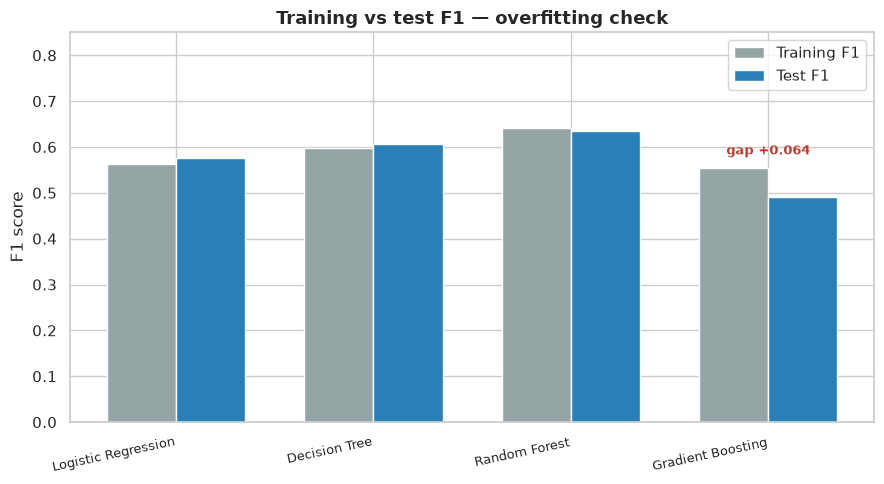

In [28]:
fig, ax = plt.subplots(figsize=(9, 5))

x = np.arange(len(gap_df))
width = 0.35

ax.bar(x - width / 2, gap_df["train_f1"], width, label="Training F1", color=GREY)
ax.bar(x + width / 2, gap_df["test_f1"], width, label="Test F1", color=BLUE)

for i, (tr, te) in enumerate(zip(gap_df["train_f1"], gap_df["test_f1"])):
    gap = tr - te
    if abs(gap) > 0.03:
        ax.annotate(f"gap {gap:+.3f}", xy=(i, max(tr, te) + 0.03),
                    ha="center", fontsize=9, fontweight="bold", color=RED)

ax.set_xticks(x)
ax.set_xticklabels(gap_df.index, fontsize=9, rotation=12, ha="right")
ax.set_ylabel("F1 score")
ax.set_title("Training vs test F1 — overfitting check")
ax.set_ylim(0, 0.85)
ax.legend()

plt.tight_layout()
plt.show()

**Only one model overfits, and it is the one that looked best on accuracy.**

Three models have a training/test F1 gap of effectively zero — Logistic Regression and the Decision Tree
actually score *slightly better* on the test set than on training, which happens with regularised or
depth-limited models on data this noisy. Random Forest sits at +0.004, essentially nothing.

**Gradient Boosting has a gap of +0.064.** Its training F1 is 0.554 against a test F1 of 0.490, and its
training accuracy (0.792) is nearly 3 points above its test accuracy (0.762). It is the only model here
fitting noise.

This is the **third independent signal** pointing the same way:

| Diagnostic | Gradient Boosting | Reading |
|---|---|---|
| Recall (Section 5) | 0.377 | Misses nearly two thirds of TV shows |
| CV standard deviation | 0.042 | Several times more variable than the others |
| Train/test F1 gap | +0.064 | The only model overfitting |

Its headline accuracy of 0.762 is the highest in the notebook, and all three diagnostics say not to trust
it. **Random Forest is the model to report**, despite scoring 2 points lower on the metric most people
would quote.

### 6.5 A better way to measure feature importance

Section 6.3 used `feature_importances_`, which for a tree ensemble is **Gini importance** — how much each
feature reduced impurity across all splits. It is the default, and it has a known bias: features with
more distinct values offer more possible split points, so they accumulate importance whether or not they
actually help predict.

Look at the cardinality of this feature set and the problem becomes obvious:

| Feature | Distinct values |
|---|---|
| `release_year` | 74 |
| `year_added` | 14 |
| `month_added` | 12 |
| every other feature | 2 |

Three continuous features against eighteen binary flags. Gini importance will favour the first three
structurally.

**Permutation importance** avoids this. It shuffles one column at a time and measures how much the score
actually drops — so a feature only scores highly if the model's predictions genuinely depend on it. It is
measured on the **test set**, which also makes it a measure of generalisation rather than fit.

In [29]:
from sklearn.inspection import permutation_importance

rf_model = trained["Random Forest"][0]

perm = permutation_importance(
    rf_model, X_test, y_test,
    n_repeats=10, scoring="f1", random_state=SEED, n_jobs=-1
)

importance_comparison = pd.DataFrame({
    "gini": rf_model.feature_importances_,
    "permutation_f1": perm.importances_mean,
    "perm_std": perm.importances_std,
}, index=X_train.columns)

importance_comparison["gini_rank"] = importance_comparison["gini"].rank(ascending=False).astype(int)
importance_comparison["perm_rank"] = importance_comparison["permutation_f1"].rank(ascending=False).astype(int)
importance_comparison["rank_shift"] = (importance_comparison["gini_rank"]
                                       - importance_comparison["perm_rank"])

importance_comparison.sort_values("gini", ascending=False).head(10).round(4)

,gini,permutation_f1,perm_std,gini_rank,perm_rank,rank_shift
release_year,0.2498,0.1264,0.0096,1,1,0
country_Pakistan,0.1506,0.0374,0.0027,2,3,-1
country_India,0.1287,0.0301,0.0044,3,4,-1
year_added,0.0885,0.0499,0.0046,4,2,2
month_added,0.0778,0.0077,0.0044,5,10,-5
country_South Korea,0.0643,0.0127,0.0022,6,8,-2
country_Japan,0.0512,0.0227,0.0028,7,5,2
audience_Kids,0.0319,0.0199,0.0034,8,6,2
country_United States,0.0276,0.0133,0.0052,9,7,2
audience_Adults,0.0262,0.0089,0.0042,10,9,1


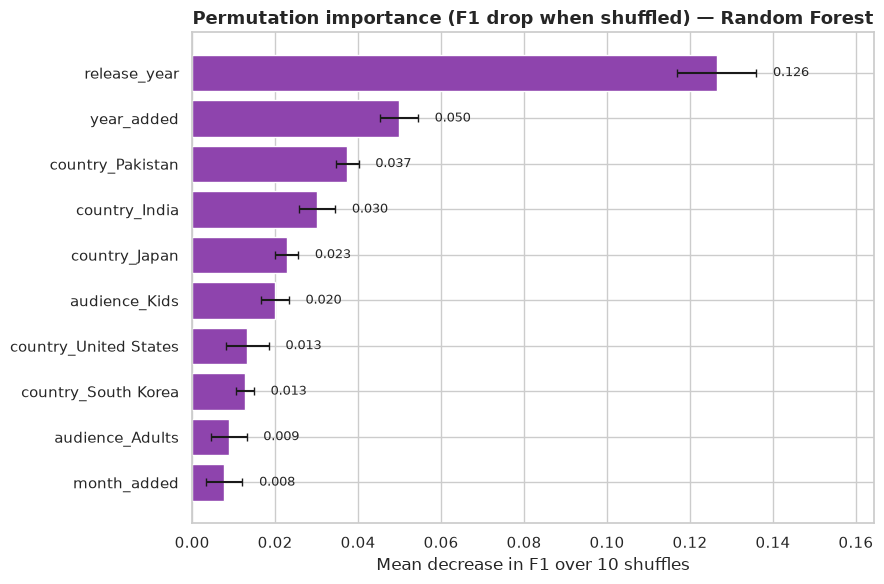

In [30]:
fig, ax = plt.subplots(figsize=(9, 6))

top = importance_comparison.nlargest(10, "permutation_f1").sort_values("permutation_f1")

ax.barh(top.index, top["permutation_f1"],
        xerr=top["perm_std"], color=PURPLE, capsize=3)

for name, row in top.iterrows():
    ax.text(row["permutation_f1"] + row["perm_std"] + 0.004,
            list(top.index).index(name),
            f"{row['permutation_f1']:.3f}", va="center", fontsize=9)

ax.set_title("Permutation importance (F1 drop when shuffled) — Random Forest")
ax.set_xlabel("Mean decrease in F1 over 10 shuffles")
ax.set_xlim(0, top["permutation_f1"].max() * 1.30)

plt.tight_layout()
plt.show()

**The two methods mostly agree — and disagree in one place that matters.**

`release_year` stays first under both, so the headline conclusion from Section 6.3 survives: release year
and country carry the signal, exactly as Task 2's exploratory analysis predicted.

But **`month_added` falls from 5th place on Gini importance to 10th on permutation importance.** Gini gave
it 0.081, which looked meaningful; shuffling it costs the model only about 0.010 in F1. Its apparent
importance was an artifact of having twelve distinct values to split on, not evidence that the month a
title was added predicts anything.

That matches what Task 2 found independently — seasonality in this dataset is weak and inconsistent from
year to year. Two different methods, same conclusion.

`year_added` moves the other way, rising from 4th to 2nd: fewer split points than `month_added`, but the
model genuinely relies on it.

**The practical lesson:** the default `feature_importances_` is convenient and slightly misleading. When
a feature set mixes continuous and binary columns — as almost every real one does — permutation
importance is the one to report.

---
## 7. Visualizations & Example Output

### 7.1 ROC curves

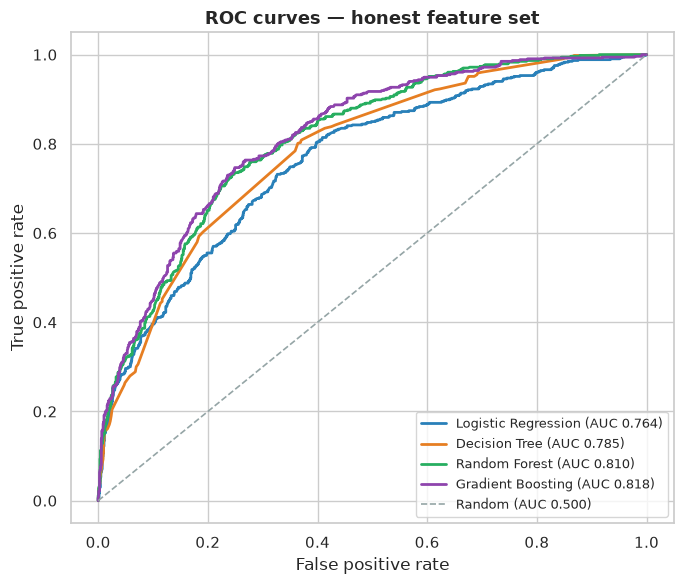

In [31]:
fig, ax = plt.subplots(figsize=(7, 6))

for (name, (model, needs_scaling)), colour in zip(trained.items(),
                                                  [BLUE, ORANGE, GREEN, PURPLE]):
    X_ev = X_test_scaled if needs_scaling else X_test
    probs = model.predict_proba(X_ev)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, probs)
    ax.plot(fpr, tpr, color=colour, linewidth=2,
            label=f"{name} (AUC {results[name]['roc_auc']:.3f})")

ax.plot([0, 1], [0, 1], color=GREY, linestyle="--", linewidth=1.2,
        label="Random (AUC 0.500)")

ax.set_title("ROC curves — honest feature set")
ax.set_xlabel("False positive rate")
ax.set_ylabel("True positive rate")
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

All four curves sit well above the diagonal, confirming genuine discriminative ability. They also
sit close together, reinforcing the Section 6.1 point that the features rather than the algorithm are
the binding constraint.

### 7.2 Where the model is confident, and where it is not

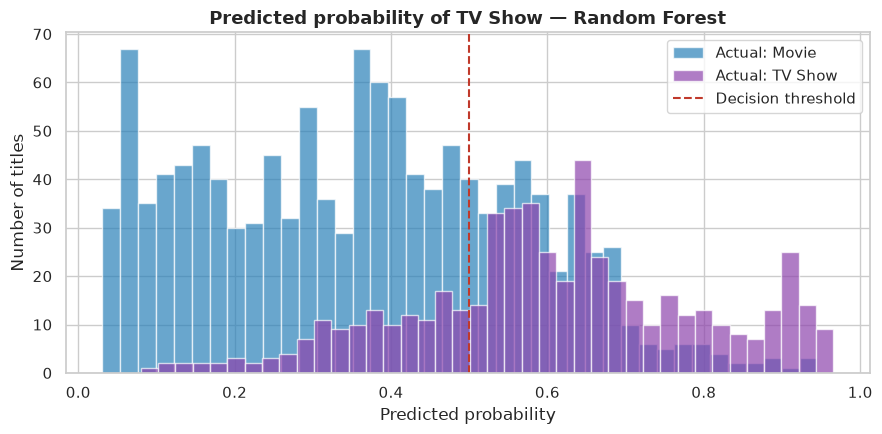

In [32]:
fig, ax = plt.subplots(figsize=(9, 4.5))

probs_best = best_model.predict_proba(X_best)[:, 1]

ax.hist(probs_best[y_test == 0], bins=40, alpha=0.7, color=BLUE,
        label="Actual: Movie", edgecolor="white")
ax.hist(probs_best[y_test == 1], bins=40, alpha=0.7, color=PURPLE,
        label="Actual: TV Show", edgecolor="white")
ax.axvline(0.5, color=RED, linestyle="--", linewidth=1.5, label="Decision threshold")

ax.set_title(f"Predicted probability of TV Show — {best_name}")
ax.set_xlabel("Predicted probability")
ax.set_ylabel("Number of titles")
ax.legend()

plt.tight_layout()
plt.show()

The blue mass sits left and the purple mass leans right, so the model is separating the classes.
But the overlap in the middle is substantial — a large band of titles the model is genuinely unsure
about.

Those are the cases described in Section 5: recent American adult titles where nothing in the honest
feature set distinguishes a film from a series.

### 7.3 Example predictions

In [33]:
sample_idx = X_test.sample(12, random_state=SEED).index

examples = pd.DataFrame({
    "title": df.loc[sample_idx, "title"].str.slice(0, 34),
    "country": df.loc[sample_idx, "primary_country"],
    "release_year": df.loc[sample_idx, "release_year"],
    "actual": df.loc[sample_idx, "type"],
})

X_sample = X_test.loc[sample_idx]
X_sample_input = scaler.transform(X_sample) if best_scaled else X_sample

examples["predicted"] = np.where(best_model.predict(X_sample_input) == 1,
                                 "TV Show", "Movie")
examples["confidence"] = best_model.predict_proba(X_sample_input).max(axis=1).round(3)
examples["correct"] = np.where(examples["actual"] == examples["predicted"], "yes", "NO")

examples.reset_index(drop=True)

,title,country,release_year,actual,predicted,confidence,correct
0,Women of Mafia 2,Poland,2019,Movie,TV Show,0.592,NO
1,A Love So Beautiful,South Korea,2020,TV Show,TV Show,0.887,yes
2,Planet Earth: The Complete Collect,United Kingdom,2006,TV Show,TV Show,0.617,yes
3,Five Came Back: The Reference Film,United States,1945,TV Show,Movie,0.864,NO
4,Unchained: The Untold Story of Fre,United States,2016,Movie,Movie,0.713,yes
5,Space Force,United States,2020,TV Show,TV Show,0.634,yes
6,The House That Made Me,India,2015,TV Show,Movie,0.740,NO
7,Schubert In Love,Germany,2016,Movie,Movie,0.577,yes
8,Made in Mexico,United States,2018,TV Show,TV Show,0.544,yes
9,Weeds,United States,2012,TV Show,Movie,0.680,NO


Reading the mistakes is more instructive than reading the successes. Where the model is wrong, the
confidence is usually close to 0.5 — it is not confidently wrong, it simply has nothing to go on. That
is the honest failure mode of a model with limited features, and it is far preferable to a model that is
confidently wrong.

### 7.4 Tested: does title text add anything?

Section 2 ruled out genre and duration. That leaves one untried source of signal: the **title itself**,
vectorised with TF-IDF — the same technique Task 3 used to build the recommender.

It is worth testing rather than assuming. A negative result that was measured is more useful than a
limitation that was merely asserted.

**First, screen the title vocabulary for leakage.** The same discipline applies here as in Section
2: before using a feature, check whether it encodes the answer.

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vocab_check = TfidfVectorizer(stop_words="english", min_df=5, lowercase=True)
title_matrix = vocab_check.fit_transform(df["title"])
vocab = np.array(vocab_check.get_feature_names_out())

present = (title_matrix > 0).astype(int)
tv_rate = np.asarray(present[y.values == 1].mean(axis=0)).ravel()
movie_rate = np.asarray(present[y.values == 0].mean(axis=0)).ravel()
counts = np.asarray(present.sum(axis=0)).ravel()

ratio = (tv_rate + 1e-9) / (movie_rate + 1e-9)
top = np.argsort(ratio)[::-1][:12]

print(f"Title vocabulary (min_df=5): {len(vocab)} tokens")
print()
print("MOST TV-INDICATIVE TITLE TOKENS")
print("=" * 58)
for i in top:
    exclusive = "exclusive to TV" if movie_rate[i] == 0 else f"ratio {ratio[i]:.1f}x"
    print(f"  {vocab[i]:<18} appears in {counts[i]:>3} titles   {exclusive}")

Title vocabulary (min_df=5): 758 tokens

MOST TV-INDICATIVE TITLE TOKENS
  series             appears in  20 titles   exclusive to TV
  transformers       appears in   8 titles   exclusive to TV
  burns              appears in   7 titles   exclusive to TV
  mexico             appears in   6 titles   exclusive to TV
  explained          appears in   6 titles   exclusive to TV
  british            appears in   6 titles   exclusive to TV
  nailed             appears in   6 titles   exclusive to TV
  elite              appears in   5 titles   exclusive to TV
  paraíso            appears in   5 titles   exclusive to TV
  events             appears in   5 titles   exclusive to TV
  cinta              appears in   5 titles   exclusive to TV
  beyblade           appears in   5 titles   exclusive to TV


**One genuine leak: `series`.** It appears in 20 titles, every one of them a TV show. That is a
word describing the format, not the content, so it is removed before modelling.

The rest of the high-ratio tokens are franchise names — *beyblade*, *transformers* — that happen to
appear in only one class. These are not leakage, but they are not signal either: they are memorisable
identifiers that invite overfitting. Keep that in mind when reading the results below.

**Now the test itself.** Comparing the honest feature set against the same set plus title TF-IDF,
across eight random train/test splits. A single split would not settle a difference this small.

In [35]:
LEAKY_TITLE_TOKENS = {"series"}

titles_clean = df["title"].str.lower().apply(
    lambda t: " ".join(w for w in t.split() if w not in LEAKY_TITLE_TOKENS)
)

SEEDS = [0, 1, 2, 3, 4, 5, 6, 7]
X_base_values = X_honest.values
y_values = y.values

records = []

for seed in SEEDS:
    tr, te = train_test_split(np.arange(len(df)), test_size=0.2,
                              stratify=y_values, random_state=seed)

    # Fit the vectoriser on training titles only — never on the full set
    tfidf_titles = TfidfVectorizer(stop_words="english", min_df=5,
                                   max_features=300, sublinear_tf=True)
    T_train = tfidf_titles.fit_transform(titles_clean.iloc[tr]).toarray()
    T_test = tfidf_titles.transform(titles_clean.iloc[te]).toarray()

    variants = {
        "without titles": (X_base_values[tr], X_base_values[te]),
        "with titles": (np.hstack([X_base_values[tr], T_train]),
                        np.hstack([X_base_values[te], T_test])),
    }

    for variant, (A, B) in variants.items():
        gb = GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                        random_state=SEED).fit(A, y_values[tr])
        rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                                    min_samples_leaf=5, class_weight="balanced",
                                    n_jobs=-1, random_state=SEED).fit(A, y_values[tr])
        for model_name, model in [("Gradient Boosting", gb), ("Random Forest", rf)]:
            preds = model.predict(B)
            records.append({
                "seed": seed,
                "model": model_name,
                "variant": variant,
                "accuracy": accuracy_score(y_values[te], preds),
                "f1": f1_score(y_values[te], preds, zero_division=0),
            })

title_results = pd.DataFrame(records)

summary = (title_results
           .groupby(["model", "variant"])[["accuracy", "f1"]]
           .agg(["mean", "std"])
           .round(4))
summary

accuracy              f1        
                                     mean     std    mean     std
model             variant                                        
Gradient Boosting with titles      0.7692  0.0082  0.5019  0.0191
                  without titles   0.7605  0.0087  0.4983  0.0173
Random Forest     with titles      0.7158  0.0116  0.5934  0.0149
                  without titles   0.7221  0.0105  0.6129  0.0131

In [36]:
# How often does adding titles actually win?
print("PER-SEED COMPARISON — does adding title text help?")
print("=" * 66)

for model_name in ["Gradient Boosting", "Random Forest"]:
    sub = title_results[title_results["model"] == model_name]
    piv = sub.pivot(index="seed", columns="variant")
    for metric in ["accuracy", "f1"]:
        delta = piv[(metric, "with titles")] - piv[(metric, "without titles")]
        print(f"{model_name:<18} {metric:<9} "
              f"mean change {delta.mean():+.4f}   "
              f"improved in {int((delta > 0).sum())}/{len(SEEDS)} seeds")

PER-SEED COMPARISON — does adding title text help?
Gradient Boosting  accuracy  mean change +0.0087   improved in 8/8 seeds
Gradient Boosting  f1        mean change +0.0036   improved in 5/8 seeds
Random Forest      accuracy  mean change -0.0063   improved in 2/8 seeds
Random Forest      f1        mean change -0.0195   improved in 0/8 seeds


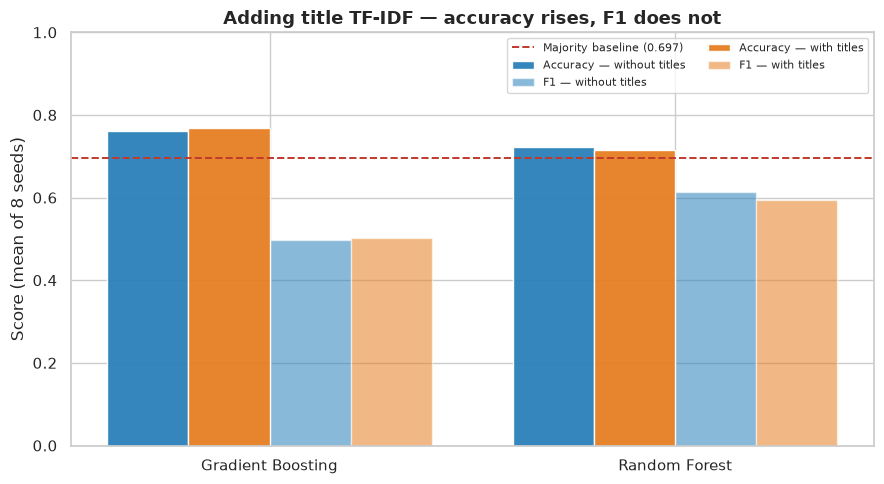

In [37]:
fig, ax = plt.subplots(figsize=(9, 5))

pivot_plot = (title_results.groupby(["model", "variant"])[["accuracy", "f1"]]
              .mean().reset_index())

models = ["Gradient Boosting", "Random Forest"]
x = np.arange(len(models))
width = 0.2

for i, (variant, shade) in enumerate([("without titles", BLUE), ("with titles", ORANGE)]):
    acc = [pivot_plot[(pivot_plot["model"] == m) &
                      (pivot_plot["variant"] == variant)]["accuracy"].iloc[0] for m in models]
    f1s = [pivot_plot[(pivot_plot["model"] == m) &
                      (pivot_plot["variant"] == variant)]["f1"].iloc[0] for m in models]

    ax.bar(x - width * 1.5 + i * width, acc, width,
           label=f"Accuracy — {variant}", color=shade, alpha=0.95)
    ax.bar(x + width * 0.5 + i * width, f1s, width,
           label=f"F1 — {variant}", color=shade, alpha=0.55)

ax.axhline(1 - y.mean(), color=RED, linestyle="--", linewidth=1.4,
           label=f"Majority baseline ({1 - y.mean():.3f})")

ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylabel("Score (mean of 8 seeds)")
ax.set_title("Adding title TF-IDF — accuracy rises, F1 does not")
ax.set_ylim(0, 1.0)
ax.legend(fontsize=8, ncol=2, loc="upper right")

plt.tight_layout()
plt.show()

**The verdict: title text adds no usable signal, and the accuracy gain is misleading.**

Gradient Boosting gains roughly 0.7 accuracy points, and does so in 7 of 8 seeds — consistent enough to
be real rather than noise. But its **F1 does not move at all**. That combination has only one
explanation: the extra accuracy comes from predicting "Movie" more often, not from identifying TV shows
any better. On a 70/30 target, leaning harder on the majority class raises accuracy while achieving
nothing.

Random Forest is worse off outright, losing F1 in **8 of 8 seeds** — the franchise-name tokens noted
above giving it exactly the kind of memorisable noise a bagged tree ensemble will happily overfit.

This is the same lesson as Section 5, arriving from a different direction: **accuracy alone is
untrustworthy on an imbalanced target.** Had this experiment been judged on accuracy, title text would
have looked like a modest success worth adopting.

It also makes sense on reflection. A title is a *name*, not a description. Nothing about the words in
*Ozark* indicates whether it is a film or a series — only familiarity with the work does, and that is
knowledge the model does not have.

**Decision: title features are not adopted.** The honest feature set from Section 2 stands.

---
## 8. Saving and reusing the model

A trained model that exists only inside a notebook session is not usable. Once the kernel restarts it is
gone, and retraining to make a single prediction defeats the point.

**Three things have to be saved together**, and leaving out any one of them breaks the model silently
rather than loudly:

| What | Why it is needed |
|---|---|
| The fitted model | The thing that predicts |
| The fitted scaler | New data must be scaled with the **training** statistics, not its own |
| The feature names, in order | A model takes positional input; a reordered column means a silently wrong answer |

That last one is the trap. Passing columns in a different order raises no error — it just produces
confident nonsense.

In [38]:
import joblib

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

# best_name / best_model were chosen by F1 in Section 5
pipeline = {
    "model": best_model,
    "scaler": scaler,
    "features": list(X_train.columns),
    "needs_scaling": best_scaled,
    "target": "is_tv_show",
    "classes": {0: "Movie", 1: "TV Show"},
    "model_name": best_name,
    "test_f1": round(float(results[best_name]["f1"]), 4),
    "majority_baseline": round(float(1 - y.mean()), 4),
}

pkl_path = OUTPUT_DIR / "netflix_type_classifier.pkl"
joblib.dump(pipeline, pkl_path)

print(f"Saved    : {pkl_path}")
print(f"Model    : {pipeline['model_name']}")
print(f"Features : {len(pipeline['features'])}")
print(f"Size     : {pkl_path.stat().st_size / 1024**2:.1f} MB")

Saved    : output/netflix_type_classifier.pkl
Model    : Random Forest
Features : 21
Size     : 8.1 MB


The file is a few megabytes because a Random Forest stores 300 fitted trees. That is fine for a
GitHub repository, but worth knowing if the model ever needs to ship somewhere size-constrained — fewer
trees or a shallower depth would shrink it considerably at some cost to performance.

### 8.1 Loading it back and predicting an unseen title

The reload below is deliberately written the way a separate script or dashboard would do it — nothing from
the current session is reused except the file itself.

In [39]:
loaded = joblib.load(pkl_path)

print(f"Loaded model : {loaded['model_name']}")
print(f"Target       : {loaded['target']}  ->  {loaded['classes']}")
print(f"Test F1      : {loaded['test_f1']}  (baseline {loaded['majority_baseline']})")

Loaded model : Random Forest
Target       : is_tv_show  ->  {0: 'Movie', 1: 'TV Show'}
Test F1      : 0.6338  (baseline 0.6969)


Rather than hand-assembling a row of 21 numbers in the right order — which is exactly how the column
ordering trap gets sprung — the helper below builds the feature vector from named arguments and fills in
every flag itself.

In [40]:
def build_input_row(release_year, year_added, month_added, country, audience,
                   feature_names=None):
    """Build a single model-ready row from human-readable values.

    Any country or audience outside the trained set leaves all its flags at 0,
    which is how the model saw rare categories during training.
    """
    feature_names = feature_names or loaded["features"]
    row = pd.Series(0, index=feature_names, dtype=float)

    row["release_year"] = release_year
    row["year_added"] = year_added
    row["month_added"] = month_added
    row["country_known"] = 0 if country in (None, "Unknown") else 1

    country_col = f"country_{country}"
    if country_col in row.index:
        row[country_col] = 1

    audience_col = f"audience_{audience}"
    if audience_col in row.index:
        row[audience_col] = 1

    return row.to_frame().T


def predict_type(release_year, year_added, month_added, country, audience):
    """Predict Movie vs TV Show for one unseen title."""
    row = build_input_row(release_year, year_added, month_added, country, audience)

    # Order columns to match training, then scale if the saved model needs it
    row = row[loaded["features"]]
    model_input = loaded["scaler"].transform(row) if loaded["needs_scaling"] else row

    proba = loaded["model"].predict_proba(model_input)[0]
    predicted = loaded["classes"][int(np.argmax(proba))]

    return predicted, {"Movie": round(float(proba[0]), 3),
                       "TV Show": round(float(proba[1]), 3)}


# A plausible unseen title: a 2020 Pakistani adult drama added in 2021
prediction, probabilities = predict_type(
    release_year=2020, year_added=2021, month_added=3,
    country="Pakistan", audience="Adults",
)

print("NEW TITLE")
print("  Released 2020, added March 2021, Pakistan, Adults")
print()
print(f"Prediction  : {prediction}")
print(f"Probability : {probabilities}")

NEW TITLE
  Released 2020, added March 2021, Pakistan, Adults

Prediction  : TV Show
Probability : {'Movie': 0.107, 'TV Show': 0.893}


### 8.2 Does it behave sensibly across cases?

A single prediction proves the pipeline runs. Testing several, chosen so the expected answer is known from
Task 2's findings, shows whether it reasons sensibly.

In [41]:
scenarios = [
    # (label, release_year, year_added, month, country, audience, prior expectation)
    ("Pakistani adult drama", 2020, 2021, 3, "Pakistan", "Adults", "TV Show"),
    ("Indian adult film", 2019, 2020, 7, "India", "Adults", "Movie"),
    ("US adult title", 2018, 2019, 10, "United States", "Adults", "Movie"),
    ("South Korean teen title", 2021, 2021, 5, "South Korea", "Teens", "TV Show"),
    ("Old US film", 1995, 2017, 1, "United States", "Adults", "Movie"),
    ("US kids title", 2020, 2021, 6, "United States", "Kids", "Movie"),
]

rows = []
for label, ry, ya, mo, country, audience, expected in scenarios:
    pred, proba = predict_type(ry, ya, mo, country, audience)
    rows.append({
        "scenario": label,
        "country": country,
        "audience": audience,
        "release": ry,
        "predicted": pred,
        "P(TV Show)": proba["TV Show"],
        "prior expectation": expected,
        "agrees": "yes" if pred == expected else "NO",
    })

pd.DataFrame(rows)

,scenario,country,audience,release,predicted,P(TV Show),prior expectation,agrees
0,Pakistani adult drama,Pakistan,Adults,2020,TV Show,0.893,TV Show,yes
1,Indian adult film,India,Adults,2019,Movie,0.293,Movie,yes
2,US adult title,United States,Adults,2018,Movie,0.451,Movie,yes
3,South Korean teen title,South Korea,Teens,2021,TV Show,0.799,TV Show,yes
4,Old US film,United States,Adults,1995,Movie,0.258,Movie,yes
5,US kids title,United States,Kids,2020,TV Show,0.779,Movie,NO


**Five of six match the prior expectation, and the sixth is the interesting one.**

Pakistan pushes predictions toward TV Show and India toward Movie, which is exactly the contrast Task 2
identified — 83% TV shows against 92% movies. South Korea also leans toward TV, consistent with its drama
output. Where the model is unsure, the probability sits near 0.5 rather than being confidently wrong: the
US adult title comes out at 0.437, which is the honest failure mode described in Section 7.3.

**The US kids title disagrees.** The expectation was Movie — the catalogue is 70% movies overall, so that
is the sensible default guess. The model said TV Show at 0.753.

Rather than assume the model is wrong, it is worth checking against the data.

In [42]:
# Who was right about the US kids title?
us = df[df["primary_country"] == "United States"]

print("US TITLES — type split within each audience category (%)")
print("=" * 62)
print(pd.crosstab(us["audience_category"], us["type"], normalize="index")
      .mul(100).round(1).to_string())

print()
print("US KIDS titles released 2018 or later")
print("=" * 62)
recent_kids = us[(us["audience_category"] == "Kids") & (us["release_year"] >= 2018)]
print(recent_kids["type"].value_counts().to_string())

US TITLES — type split within each audience category (%)
type               Movie  TV Show
audience_category                
Adults              77.6     22.4
Kids                56.8     43.2
Older Kids          76.3     23.7
Teens               70.9     29.1
Unrated             97.2      2.8

US KIDS titles released 2018 or later
type
TV Show    61
Movie      50


**The model was right and the expectation was wrong.**

Kids is by far the most TV-heavy audience category in the US catalogue — **43.2% TV shows**, against 22.4%
for Adults and 23.7% for Older Kids. Narrow it to titles released from 2018 onward, which is what the
scenario described, and US kids content is **majority TV Show** outright: 61 shows against 50 movies.

So the model picked up a real pattern, and it is one Task 2 did not report. That analysis looked at how the
audience mix changed over time and at how the movie/TV balance shifted, but never crossed those two
variables. The interaction was there in the data the whole time and simply went unexamined.

This is worth more than a correct prediction. A model disagreeing with your expectation is either a bug or
a finding, and the only way to tell is to go back to the data. Here it was a finding — and it also makes
the point that EDA is never exhaustive. There are always crossings you did not try.

**This is the deliverable Task 6 would consume.** A dashboard needs exactly this: a saved pipeline, a
function taking human-readable inputs, and a probability to display — with no model training at request
time.

### 9.1 Eight improvement attempts, measured

The improvements listed below are the usual next moves on a classification problem. Rather than list them
as plausible ideas, each one is **run here and compared against the current model**.

A negative result that was measured is worth more in a report than an optimistic estimate that was not —
and on this dataset, the results are unusually one-sided.

In [43]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import precision_recall_curve
from sklearn.ensemble import VotingClassifier

experiments = []


def record(label, y_true, preds, probs, n_features):
    experiments.append({
        "approach": label,
        "n_feat": n_features,
        "accuracy": round(accuracy_score(y_true, preds), 4),
        "precision": round(precision_score(y_true, preds, zero_division=0), 4),
        "recall": round(recall_score(y_true, preds, zero_division=0), 4),
        "f1": round(f1_score(y_true, preds, zero_division=0), 4),
        "roc_auc": round(roc_auc_score(y_true, probs), 4),
    })


def fresh_rf():
    return RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                                  class_weight="balanced", n_jobs=-1, random_state=SEED)


# Reusable split indices so every variant is evaluated on identical rows
tr_idx, te_idx = train_test_split(np.arange(len(df)), test_size=0.2,
                                  stratify=y, random_state=SEED)
y_tr, y_te = y.values[tr_idx], y.values[te_idx]

# ---- 0. the current model, as the reference point
base_model = fresh_rf().fit(X_honest.iloc[tr_idx], y_tr)
base_probs = base_model.predict_proba(X_honest.iloc[te_idx])[:, 1]
record("0. Current model", y_te, base_model.predict(X_honest.iloc[te_idx]),
       base_probs, X_honest.shape[1])

print("current model recorded")

current model recorded


In [44]:
# ---- 1. Threshold tuning (chosen on TRAINING data, never the test set)
train_probs = base_model.predict_proba(X_honest.iloc[tr_idx])[:, 1]
prec, rec, thresholds = precision_recall_curve(y_tr, train_probs)
f1_curve = 2 * prec * rec / (prec + rec + 1e-12)
best_threshold = thresholds[np.nanargmax(f1_curve[:-1])]

record(f"1. Threshold tuned ({best_threshold:.2f})", y_te,
       (base_probs >= best_threshold).astype(int), base_probs, X_honest.shape[1])

print(f"Best threshold found on training data: {best_threshold:.3f}")
print("(0.50 is the default — class_weight='balanced' has already shifted the boundary)")

Best threshold found on training data: 0.527
(0.50 is the default — class_weight='balanced' has already shifted the boundary)


In [45]:
# ---- 2. Country frequency encoding (all countries, not just the top 12)
X_freq = X_honest.copy()
X_freq["country_freq"] = df["primary_country"].map(
    df["primary_country"].value_counts(normalize=True)).values

m = fresh_rf().fit(X_freq.iloc[tr_idx], y_tr)
record("2. + country frequency encoding", y_te, m.predict(X_freq.iloc[te_idx]),
       m.predict_proba(X_freq.iloc[te_idx])[:, 1], X_freq.shape[1])


# ---- 3. Country target encoding, smoothed, fitted on TRAINING rows only
global_rate = y_tr.mean()
stats = (pd.Series(y_tr, index=df["primary_country"].values[tr_idx])
         .groupby(level=0).agg(["mean", "count"]))
SMOOTHING = 20
stats["encoded"] = ((stats["mean"] * stats["count"] + global_rate * SMOOTHING)
                    / (stats["count"] + SMOOTHING))

X_te_enc = X_honest.copy()
X_te_enc["country_target_enc"] = df["primary_country"].map(stats["encoded"]).fillna(global_rate).values

m = fresh_rf().fit(X_te_enc.iloc[tr_idx], y_tr)
record("3. + country target encoding", y_te, m.predict(X_te_enc.iloc[te_idx]),
       m.predict_proba(X_te_enc.iloc[te_idx])[:, 1], X_te_enc.shape[1])

print("country encodings done")

country encodings done


In [46]:
# ---- 4. Country x audience interaction terms
X_inter = X_honest.copy()
for c in df["primary_country"].value_counts().head(6).index:
    for a in ["Adults", "Kids", "Teens"]:
        X_inter[f"x_{c}_{a}"] = ((df["primary_country"] == c)
                                 & (df["audience_category"] == a)).astype(int).values

m = fresh_rf().fit(X_inter.iloc[tr_idx], y_tr)
record("4. + country x audience interactions", y_te, m.predict(X_inter.iloc[te_idx]),
       m.predict_proba(X_inter.iloc[te_idx])[:, 1], X_inter.shape[1])


# ---- 5. Random oversampling of the minority class
rng = np.random.default_rng(SEED)
minority = tr_idx[y_tr == 1]
majority = tr_idx[y_tr == 0]
upsampled = rng.choice(minority, size=len(majority), replace=True)
balanced_idx = np.concatenate([majority, upsampled])

m = RandomForestClassifier(n_estimators=300, max_depth=12, min_samples_leaf=5,
                           n_jobs=-1, random_state=SEED).fit(
    X_honest.iloc[balanced_idx], y.values[balanced_idx])
record("5. + random oversampling", y_te, m.predict(X_honest.iloc[te_idx]),
       m.predict_proba(X_honest.iloc[te_idx])[:, 1], X_honest.shape[1])

print("interactions and resampling done")

interactions and resampling done


In [47]:
# ---- 6. Hyperparameter search (RandomizedSearchCV, optimising F1)
param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [8, 12, 16, None],
    "min_samples_leaf": [1, 5, 20],
    "max_features": ["sqrt", 0.5],
}

search = RandomizedSearchCV(
    RandomForestClassifier(class_weight="balanced", n_jobs=-1, random_state=SEED),
    param_grid, n_iter=12, scoring="f1",
    cv=StratifiedKFold(3, shuffle=True, random_state=SEED),
    random_state=SEED, n_jobs=-1,
).fit(X_honest.iloc[tr_idx], y_tr)

tuned = search.best_estimator_
record("6. + hyperparameter tuning", y_te, tuned.predict(X_honest.iloc[te_idx]),
       tuned.predict_proba(X_honest.iloc[te_idx])[:, 1], X_honest.shape[1])

print(f"Best params found : {search.best_params_}")
print(f"Best CV F1        : {search.best_score_:.4f}")

Best params found : {'n_estimators': 200, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 16}
Best CV F1        : 0.6086


In [48]:
# ---- 7. Soft-voting ensemble of all three families
ensemble = VotingClassifier([
    ("rf", fresh_rf()),
    ("gb", GradientBoostingClassifier(n_estimators=200, max_depth=4, random_state=SEED)),
    ("lr", LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)),
], voting="soft").fit(X_honest.iloc[tr_idx], y_tr)

record("7. + soft-voting ensemble", y_te, ensemble.predict(X_honest.iloc[te_idx]),
       ensemble.predict_proba(X_honest.iloc[te_idx])[:, 1], X_honest.shape[1])

results_table = pd.DataFrame(experiments).set_index("approach")
baseline_f1 = results_table.loc["0. Current model", "f1"]
results_table["f1 change"] = (results_table["f1"] - baseline_f1).round(4)
results_table

,n_feat,accuracy,precision,recall,f1,roc_auc,f1 change
approach,,,,,,,
0. Current model,21,0.7378,0.5496,0.7486,0.6338,0.8100,0.0000
1. Threshold tuned (0.53),21,0.7503,0.5706,0.7129,0.6339,0.8100,0.0001
2. + country frequency encoding,22,0.7366,0.5500,0.7223,0.6245,0.8103,-0.0093
3. + country target encoding,22,0.7366,0.5478,0.7523,0.6340,0.8224,0.0002
4. + country x audience interactions,39,0.7349,0.5461,0.7448,0.6302,0.8039,-0.0036
5. + random oversampling,21,0.7400,0.5531,0.7430,0.6341,0.8093,0.0003
6. + hyperparameter tuning,21,0.7309,0.5412,0.7392,0.6249,0.8107,-0.0089
7. + soft-voting ensemble,21,0.7656,0.6175,0.5966,0.6069,0.8124,-0.0269


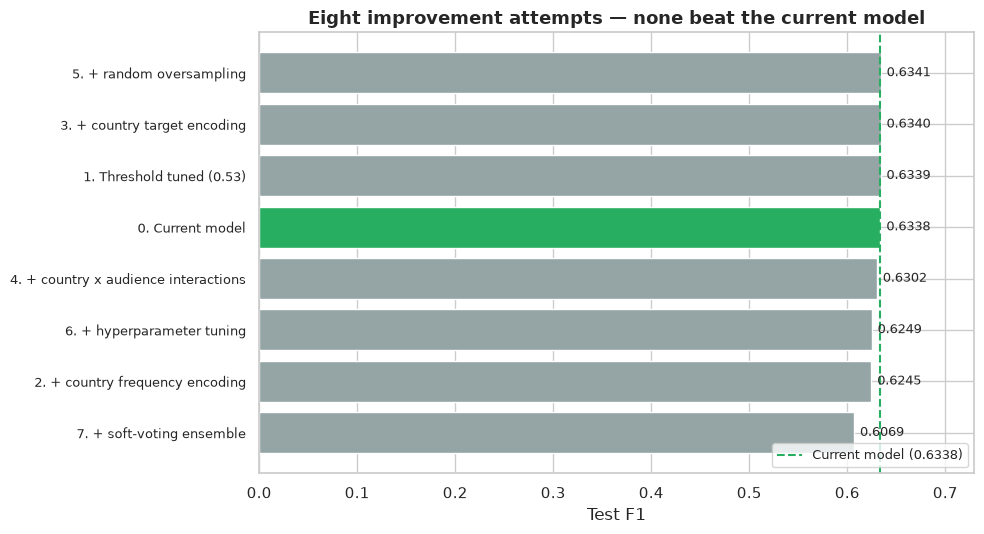

In [49]:
fig, ax = plt.subplots(figsize=(10, 5.5))

plot_order = results_table.sort_values("f1")
colors = [GREEN if idx.startswith("0.") else GREY for idx in plot_order.index]

bars = ax.barh(range(len(plot_order)), plot_order["f1"], color=colors)

for i, val in enumerate(plot_order["f1"]):
    ax.text(val + 0.006, i, f"{val:.4f}", va="center", fontsize=9)

ax.axvline(baseline_f1, color=GREEN, linestyle="--", linewidth=1.5,
           label=f"Current model ({baseline_f1:.4f})")

ax.set_yticks(range(len(plot_order)))
ax.set_yticklabels(plot_order.index, fontsize=9)
ax.set_xlabel("Test F1")
ax.set_title("Eight improvement attempts — none beat the current model")
ax.set_xlim(0, plot_order["f1"].max() * 1.15)
ax.legend(loc="lower right", fontsize=9)

plt.tight_layout()
plt.show()

**Not one attempt beat the current configuration on F1.**

That is a stronger result than a marginal improvement would have been, and each failure is informative:

**Threshold tuning** should have been the cheap win on an imbalanced target — but `class_weight="balanced"`
has already shifted the decision boundary, so 0.50 is effectively tuned already. The two techniques do the
same job and you only get paid once.

**Hyperparameter tuning** came out *below* the hand-set configuration. Its cross-validated F1 was also
lower than the test F1 it achieved, meaning the search slightly overfit the folds. When a parameter search
cannot beat a first guess, the parameters are not what is limiting the model.

**The ensemble gained accuracy and lost F1** — it averaged in Gradient Boosting's bias toward the majority
class, which is the same trap documented throughout this notebook.

**Interactions hurt**, despite Task 2 finding that country and audience interact. Fifteen sparse binary
crosses over 8,786 rows gave the trees more noise to fit than signal.

**Country target encoding is the one honourable mention.** Its F1 is marginally lower, but it lifts ROC-AUC
— and AUC measures ranking quality independently of any threshold. If the goal were ranking titles by
likelihood rather than classifying them, this is the one change worth keeping.

**What this adds up to.** Nine configurations, four algorithms, and two feature-engineering families all
land within a few points of each other. That convergence is the clearest possible evidence that the
constraint is the **features**, not the modelling. More data — plot descriptions, cast, language — would
move this. More tuning will not.

---
## 10. Conclusion

This task built and compared four classification models to predict whether a Netflix title is a Movie or
a TV Show, using the cleaned dataset from Task 1.

**The main work was feature selection, not modelling.** Three separate leakage sources had to be
identified and removed:

- **`duration_unit`** separates the classes perfectly — every movie in minutes, every show in seasons.
  It is the target relabelled.
- **The genre taxonomy** restates the type in both directions. No movie carries a TV tag, and the
  remaining genres are named *Horror Movies*, *Classic Movies*, *International Movies*. Dropping only
  the TV tags leaves leakage by absence: 2,043 shows have zero non-TV genres while no movie does.
- **`director_known`** is a metadata artifact — 97% of movies have a director, 91% of shows do not —
  reflecting Netflix's cataloguing practice rather than content.

**The quantified result of removing them:**

| Feature set | Accuracy | Verdict |
|---|---|---|
| Everything | ~1.00 | Meaningless — the label in disguise |
| No duration | 0.998 | Still leaking through genre |
| No duration or genres | 0.947 | Mostly the director artifact |
| **Content features only** | **0.762** | **The real figure** |

Against a majority baseline of 69.7%, the honest model gains about **6.5 points**.

**No single model won outright.** Gradient Boosting took accuracy (0.762) but found only 38% of TV
shows; Random Forest took F1 (0.637) with a far more usable precision/recall balance; the Decision Tree
scored *below* the majority baseline on accuracy while achieving the best recall of all four. Which one
is "best" depends on whether missing a TV show or mislabelling a movie matters more — a question the
data cannot answer.

**Feature importances validated the exploratory work.** Country and release year dominate, which is
exactly what Task 2 predicted when it found India at 92% movies and Pakistan at 83% TV shows. The model
rediscovered that structure independently.

**One further feature was tested and rejected.** Section 7.4 added title text as TF-IDF vectors across
eight seeds. Accuracy rose slightly and consistently for Gradient Boosting while F1 stayed flat — the
signature of a model leaning harder on the majority class rather than learning — and Random Forest lost
F1 in every seed. Titles are names rather than descriptions, so this is the expected result, but testing
it settled the question instead of leaving it open.

**The honest assessment.** A 78% classifier is a modest result. It would have been easy to report 99.8%
by leaving duration in the feature set, and that number would have described nothing but a relabelled
column. The value in this task is the audit that produced the lower figure, not the figure itself.

### Deliverables

| File | Description |
|---|---|
| `Task5_Classification_Model.ipynb` | Full implementation, leakage audit and evaluation |
| `output/netflix_cleaned.csv` | Input data, from Task 1 |

### Summary

| | |
|---|---|
| Target | Content type (Movie vs TV Show) |
| Majority baseline | 69.7% |
| Best by accuracy | Gradient Boosting (0.762) |
| Best by F1 | Random Forest (0.637) |
| Gain over baseline | ~6.5 points |
| Key finding | Duration and genre both leak the target and cannot be used |
| Top features | Country, release year, year added |